# Logistic Regression — From Scratch vs Scikit-learn

Binary classification using gradient descent, built in NumPy and verified against sklearn.

## Dataset

- 100 samples, 2 features, 2 classes
- `n_informative=1` — only one feature actually drives the separation
- `class_sep=20` — high separation, making the data cleanly linearly separable
- `random_state=41` — reproducible

In [45]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [46]:
import matplotlib.pyplot as plt

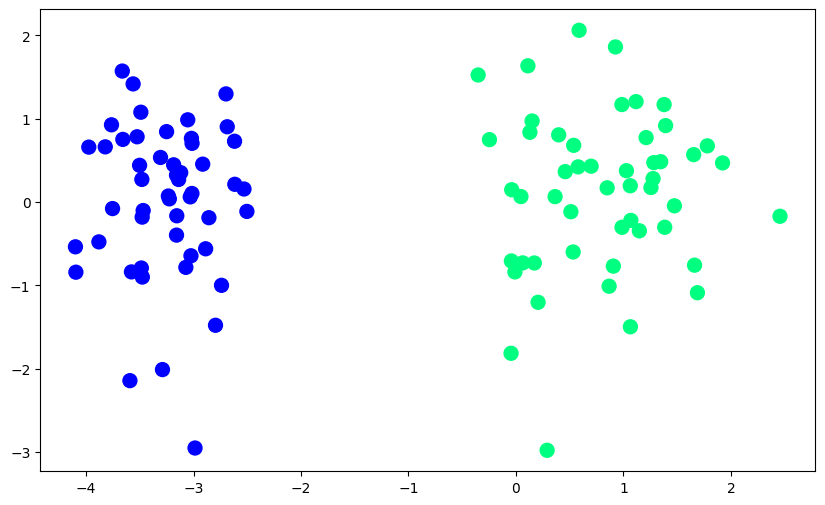

In [47]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [49]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(solver='sag')
lor.fit(X,y)

LogisticRegression(solver='sag')

## Decision Boundary (from coefficients)

To plot the boundary, solve for x₂ when the decision function = 0:


w₀x₁ + w₁x₂ + b = 0.  
→ x₂ = -(w₀/w₁)x₁ - (b/w₁)                    
→ slope m = -(w₀/w₁), intercept b = -(b/w₁)        


(-3.0, 2.0)

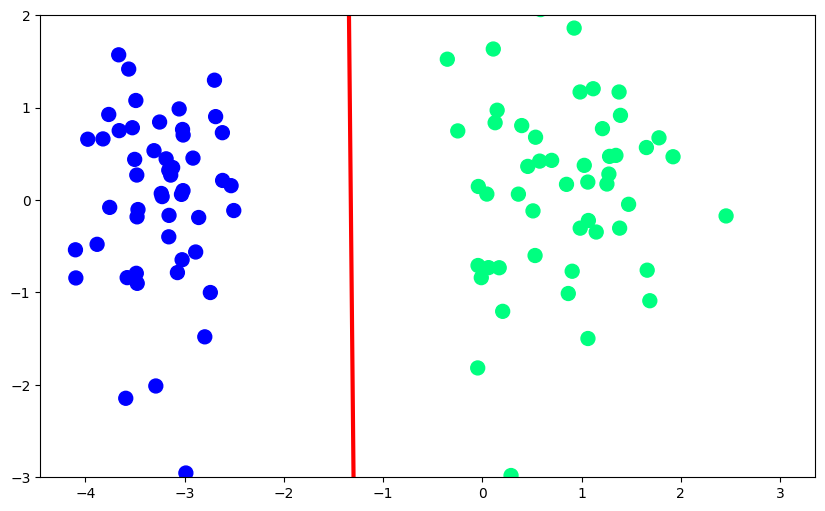

In [48]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)


**Key steps:**
1. Prepend a column of 1s to X → bias becomes just another weight
2. Initialize all weights to 1
3. For each iteration:
   - Forward pass: `ŷ = σ(X · w)`
   - Compute residual: `(y - ŷ)`
   - Update: `w = w + lr * Xᵀ(y - ŷ) / n`

**Why `+` and not `-`?**  
This is gradient *ascent* on the log-likelihood, not descent on the loss — they're equivalent, just flipped sign convention.

**Hyperparameters:** `lr = 0.5`, `iterations = 5000`

In [50]:
def gd(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
def sigmoid(z):
    return 1/(1 + np.exp(-z))
        

In [51]:
print(lor.coef_)
print(lor.intercept_)

[[2.36714416 0.02157868]]
[3.13778191]


In [52]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [53]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [54]:
coef_,intercept_ = gd(X,y)

In [55]:
m = -(coef_[0]/coef_[1])

b = -(intercept_/coef_[1])

In [56]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

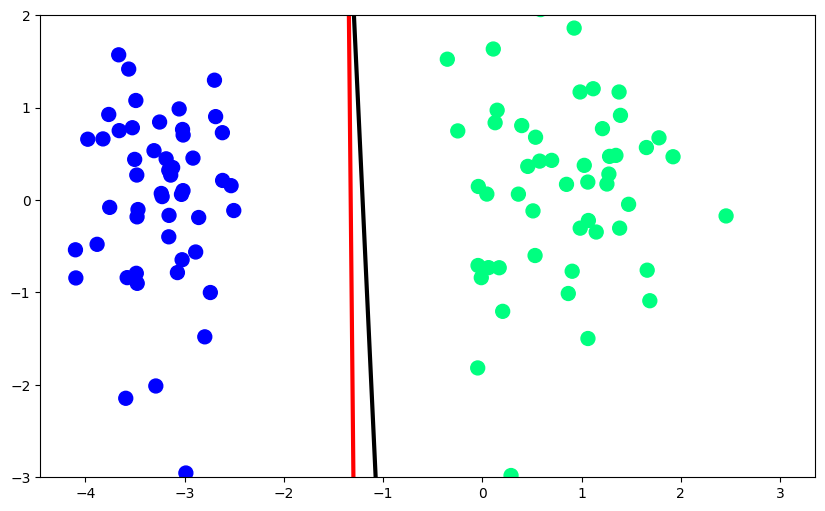

In [57]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

## Key Takeaways

- The gradient update for logistic regression looks identical to linear regression — the math works out cleanly when you differentiate cross-entropy through the sigmoid
- `np.insert(X, 0, 1, axis=1)` folds the intercept into the weight vector — one dot product instead of `w·x + b`
- `penalty='none'` is critical for a fair comparison — any regularization would shift the sklearn boundary
- High `class_sep` here means GD converges fast; messy real data needs more tuning